In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

In [45]:
df = pd.read_csv('breast_cancer_data.csv')
df['diagnosis'] = df['diagnosis'].replace({'M':1,'B':0})

# Predictor variables
predictor_var = ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']
outcome_var = 'diagnosis'

print(df.head())
print(df.diagnosis.value_counts())

         id  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302          1        17.99         10.38          122.80     1001.0   
1    842517          1        20.57         17.77          132.90     1326.0   
2  84300903          1        19.69         21.25          130.00     1203.0   
3  84348301          1        11.42         20.38           77.58      386.1   
4  84358402          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoo

C:\Users\apexf\AppData\Local\Temp\ipykernel_20300\122945717.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'] = df['diagnosis'].replace({'M':1,'B':0})


Unique IDs equal sample size: True
Max features allowed: 21.2


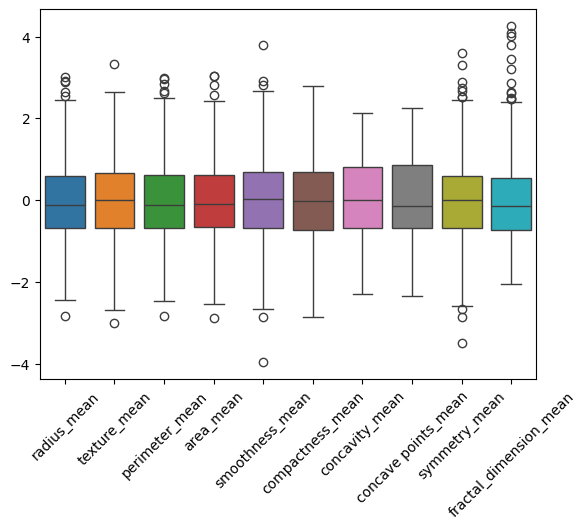

In [46]:
# Check unique IDs
print("Unique IDs equal sample size:", df.id.nunique()==df.id.count())

# Max features rule
max_features = min(df.diagnosis.value_counts()/10)
print("Max features allowed:", max_features)

# Boxplot of zscores
sns.boxplot(data=np.log(df[predictor_var]+.01).apply(zscore))
plt.xticks(rotation=45)
plt.show()
plt.close()

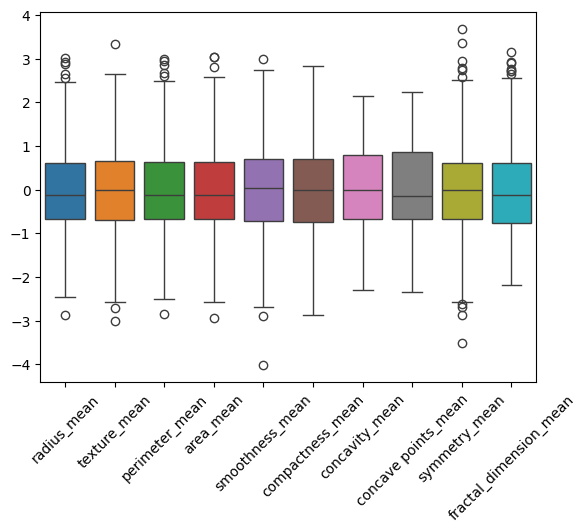

In [47]:
# Filter extreme outliers
q_hi  = df["fractal_dimension_mean"].quantile(0.99)
df_filtered = df[(df["fractal_dimension_mean"] < q_hi)]

sns.boxplot(data=np.log(df_filtered[predictor_var]+.01).apply(zscore))
plt.xticks(rotation=45)
plt.show()
plt.close()

# Simplified predictor set
predictor_var = ['radius_mean', 'texture_mean', 'compactness_mean','symmetry_mean']

In [48]:
# Train/test split
x_train, x_test, y_train, y_test = train_test_split(df[predictor_var], df[outcome_var], random_state=0, test_size=0.3)

# Logistic regression model
log_reg = LogisticRegression(penalty=None, fit_intercept=True, solver='newton-cg', max_iter=1000)
log_reg.fit(x_train, y_train)

print("Coefficients:", log_reg.coef_)
print("Intercept:", log_reg.intercept_)

Coefficients: [[ 1.0795747   0.28739327 30.99258835 29.90273742]]
Intercept: [-30.14050062]


In [49]:
# Metrics
y_pred = log_reg.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

# Confusion matrix
cm = pd.DataFrame(confusion_matrix(y_test, y_pred),
                  index=['actual 0','actual 1'],
                  columns=['predicted 0','predicted 1'])
print(cm)

Accuracy: 0.9064327485380117
Precision: 0.8507462686567164
Recall: 0.9047619047619048
F1: 0.8769230769230769
          predicted 0  predicted 1
actual 0           98           10
actual 1            6           57


In [50]:
# Threshold analysis
y_pred_prob = log_reg.predict_proba(x_test)
y_pred_class = (y_pred_prob[:,1]>0.5).astype(int)
print("Same as y_pred?", np.array_equal(y_pred_class,y_pred))

print("Confusion Matrix @ 0.25:\n", confusion_matrix(y_test,(y_pred_prob[:,1]>0.25).astype(int)))
print("Confusion Matrix @ 0.75:\n", confusion_matrix(y_test,(y_pred_prob[:,1]>0.75).astype(int)))

Same as y_pred? True
Confusion Matrix @ 0.25:
 [[94 14]
 [ 2 61]]
Confusion Matrix @ 0.75:
 [[104   4]
 [ 11  52]]


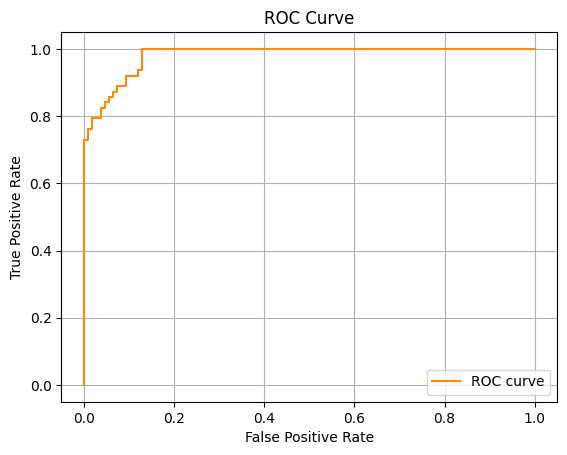

ROC AUC score: 0.9810405643738976


In [51]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_pred_prob[:,1])
plt.figure()
plt.plot(fpr, tpr, color='darkorange', label='ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid()
plt.legend(loc="lower right")
plt.show()

roc_auc = roc_auc_score(y_test, y_pred_prob[:,1])
print("ROC AUC score:", roc_auc)

In [52]:
x_train_str, x_test_str, y_train_str, y_test_str = train_test_split(
    df[predictor_var], df[outcome_var], random_state=6, test_size=0.3, stratify=df[outcome_var])

# Positivity rates
str_train_positivity_rate = y_train_str.mean()
str_test_positivity_rate = y_test_str.mean()
print("Stratified train positivity rate:", str_train_positivity_rate)
print("Stratified test positivity rate:", str_test_positivity_rate)

# Fit model on stratified sample
log_reg_str = LogisticRegression(penalty=None, max_iter=1000, fit_intercept=True, solver='newton-cg')
log_reg_str.fit(x_train_str, y_train_str)
y_pred_str = log_reg_str.predict(x_test_str)

Stratified train positivity rate: 0.37185929648241206
Stratified test positivity rate: 0.3742690058479532


In [53]:
recall_str = recall_score(y_test_str, y_pred_str)
accuracy_str = accuracy_score(y_test_str, y_pred_str)
print("Stratified Recall:", recall_str)
print("Stratified Accuracy:", accuracy_str)

# Balanced Class Weights
log_reg_bal = LogisticRegression(penalty=None, max_iter=1000, fit_intercept=True, solver='newton-cg', class_weight='balanced')
log_reg_bal.fit(x_train, y_train)
y_pred_bal = log_reg_bal.predict(x_test)

recall_bal = recall_score(y_test, y_pred_bal)
accuracy_bal = accuracy_score(y_test, y_pred_bal)
print("Balanced Recall:", recall_bal)
print("Balanced Accuracy:", accuracy_bal)

Stratified Recall: 0.875
Stratified Accuracy: 0.9239766081871345
Balanced Recall: 0.9206349206349206
Balanced Accuracy: 0.9122807017543859
